# Run RAG Query

This notebook is to run the RAG query. 

In [3]:
from pathlib import Path
from typing import List

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import PyPDFLoader

# Load documents as PDFs
from langchain_community.document_loaders import PyPDFLoader

# Chunk documents
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Embedding Model
from langchain_community.embeddings import HuggingFaceEmbeddings

# Create vector DB
from langchain_community.vectorstores import FAISS

print("Imports loaded.")

from rank_bm25 import BM25Okapi
from langchain_core.documents import Document
import re
import numpy as np

/Users/julie/Documents/github/ds593_finalproject/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports loaded.


# Reload Vector DB 

In [4]:
# Embedding Model. Using free tier AI
# from langchain_community.embeddings import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True}
)

/var/folders/r_/329g_gv939xfmdlhmvswc5bm0000gn/T/ipykernel_88197/1172382142.py:4: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10938.71it/s]


In [5]:
from langchain_community.vectorstores import FAISS

# Paths for each vector DB
fixed_vector_path = "fixed_rag_faiss_index"
structure_path = "faiss_structure_chunks"
sentence_path = "faiss_sentence_chunks"
semantic_path = "faiss_semantic_chunks"

# Load each vector DB

fixed_vector_db = FAISS.load_local(
    fixed_vector_path,
    embeddings,
    allow_dangerous_deserialization=True
)

structure_vector_db = FAISS.load_local(
    structure_path,
    embeddings,
    allow_dangerous_deserialization=True
)

sentence_vector_db = FAISS.load_local(
    sentence_path,
    embeddings,
    allow_dangerous_deserialization=True
)

semantic_vector_db = FAISS.load_local(
    semantic_path,
    embeddings,
    allow_dangerous_deserialization=True
)

print("Vector DB reloaded from local folder.")

Vector DB reloaded from local folder.


In [6]:
# Store all 4 vector DBs in one dictionary

vector_dbs = {
    "fixed_size": fixed_vector_db,
    "document_structure": structure_vector_db,
    "sentence": sentence_vector_db,
    "semantic": semantic_vector_db
}

print("Available vector DBs:", list(vector_dbs.keys()))

Available vector DBs: ['fixed_size', 'document_structure', 'sentence', 'semantic']


In [7]:
# Load local Hugging Face model for answer generation
# TinyLlama is a causal model, so we must format the prompt as chat and decode ONLY new tokens.

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_id)

# Use CPU-safe loading. If you have a GPU, you can change this later.
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float32,
    device_map=None
)

model.eval()
print("LLM loaded.")


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 201/201 [00:04<00:00, 46.96it/s]

LLM loaded.


In [8]:
def llm(prompt: str, max_new_tokens: int = 350) -> str:
    """
    Generate an answer using TinyLlama.
    Important fix: decode only the newly generated tokens, not the full prompt.
    """

    messages = [
        {
            "role": "system",
            "content": (
                "You are a careful RAG assistant. Answer only from the provided context. "
                "Use citations exactly as provided, such as [1] or [1, p. 3]. "
                "If the context does not answer the question, say that the documents do not contain enough information."
                "Do not stop mid-sentence."
            )
        },
        {"role": "user", "content": prompt}
    ]

    formatted_prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        formatted_prompt,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    # CRITICAL FIX: remove the prompt tokens from the output
    new_tokens = outputs[0][inputs["input_ids"].shape[-1]:]
    answer = tokenizer.decode(new_tokens, skip_special_tokens=True)

    return answer.strip()


In [9]:
# def retrieve_chunks(query: str, vector_db, k: int = 4):
#     """Retrieve top-k chunks from a selected FAISS vector database."""
#     return vector_db.similarity_search(query, k=k)


# # Quick retrieval test
# test_chunks = retrieve_chunks(
#     "What is copyright?",
#     vector_dbs["fixed_size"],
#     k=4
# )

# print(f"Retrieved {len(test_chunks)} chunks")

# for i, doc in enumerate(test_chunks, start=1):
#     print(f"\nChunk {i}")
#     print("Source:", doc.metadata.get("source_file", "Unknown file"))
#     print("Page:", doc.metadata.get("page", "Unknown page"))
#     print("Chunking:", doc.metadata.get("chunking_method", "fixed_size"))
#     print("Citation:", doc.metadata.get("ieee_citation", "Unknown citation"))
#     print("Preview:", doc.page_content[:250].replace("\n", " "))

In [10]:
# Different retrieval methods 

def retrieve_similarity(query: str, vector_db, k: int = 4):
    """Standard vector similarity search."""
    return vector_db.similarity_search(query, k=k)


def retrieve_mmr(query: str, vector_db, k: int = 4, fetch_k: int = 20):
    """
    MMR = Maximal Marginal Relevance.
    Good when you want diverse chunks instead of very similar repeated chunks.
    """
    return vector_db.max_marginal_relevance_search(
        query,
        k=k,
        fetch_k=fetch_k
    )


def retrieve_with_scores(query: str, vector_db, k: int = 4):
    """
    Vector search but keeps similarity scores in metadata.
    """
    results = vector_db.similarity_search_with_score(query, k=k)

    docs = []
    for doc, score in results:
        doc.metadata["similarity_score"] = float(score)
        docs.append(doc)

    return docs


def retrieve_threshold(query: str, vector_db, k: int = 8, max_score: float = 1.0):
    """
    Keeps only chunks under a distance threshold.
    For FAISS, lower score usually means more similar.
    Adjust max_score after inspecting your scores.
    """
    results = vector_db.similarity_search_with_score(query, k=k)

    filtered_docs = []
    for doc, score in results:
        if score <= max_score:
            doc.metadata["similarity_score"] = float(score)
            filtered_docs.append(doc)

    return filtered_docs

In [11]:
# BM25 keyword retrieval 

def tokenize(text: str):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return text.split()


def build_bm25_index(vector_db):
    """
    Extracts documents from a FAISS vector DB and builds a BM25 keyword index.
    """
    docs = list(vector_db.docstore._dict.values())
    tokenized_docs = [tokenize(doc.page_content) for doc in docs]
    bm25 = BM25Okapi(tokenized_docs)

    return docs, bm25


bm25_indexes = {}

for method_name, db in vector_dbs.items():
    docs, bm25 = build_bm25_index(db)
    bm25_indexes[method_name] = {
        "docs": docs,
        "bm25": bm25
    }

print("BM25 indexes built for:", list(bm25_indexes.keys()))

BM25 indexes built for: ['fixed_size', 'document_structure', 'sentence', 'semantic']


In [12]:
def retrieve_bm25(query: str, method_name: str, k: int = 4):
    """
    Keyword-based retrieval.
    Good when the question uses exact terms from the papers.
    """
    docs = bm25_indexes[method_name]["docs"]
    bm25 = bm25_indexes[method_name]["bm25"]

    tokenized_query = tokenize(query)
    scores = bm25.get_scores(tokenized_query)

    top_indices = np.argsort(scores)[::-1][:k]

    retrieved_docs = []
    for idx in top_indices:
        doc = docs[idx]
        doc.metadata["bm25_score"] = float(scores[idx])
        retrieved_docs.append(doc)

    return retrieved_docs

In [13]:
# hybrid retrieval: BM25 + vector search 

def retrieve_hybrid(query: str, vector_db, method_name: str, k: int = 4, vector_k: int = 8, bm25_k: int = 8):
    """
    Hybrid retrieval combines:
    1. semantic vector search
    2. keyword BM25 search

    This is usually stronger than either one alone.
    """
    vector_docs = retrieve_similarity(query, vector_db, k=vector_k)
    bm25_docs = retrieve_bm25(query, method_name, k=bm25_k)

    combined = []
    seen = set()

    for doc in vector_docs + bm25_docs:
        key = doc.page_content[:200]

        if key not in seen:
            combined.append(doc)
            seen.add(key)

        if len(combined) >= k:
            break

    return combined

In [14]:
# unified retrieval method 
def retrieve_chunks(
    query: str,
    vector_db,
    method_name: str,
    retrieval_method: str = "similarity",
    k: int = 4
):
    """
    Select retrieval method.
    """

    if retrieval_method == "similarity":
        return retrieve_similarity(query, vector_db, k=k)

    elif retrieval_method == "mmr":
        return retrieve_mmr(query, vector_db, k=k)

    elif retrieval_method == "with_scores":
        return retrieve_with_scores(query, vector_db, k=k)

    elif retrieval_method == "threshold":
        return retrieve_threshold(query, vector_db, k=k)

    elif retrieval_method == "bm25":
        return retrieve_bm25(query, method_name, k=k)

    elif retrieval_method == "hybrid":
        return retrieve_hybrid(query, vector_db, method_name, k=k)

    else:
        raise ValueError(f"Unknown retrieval method: {retrieval_method}")

In [15]:
def rag_query(question: str, vector_db, method_name: str, retrieval_method: str = "similarity", k: int = 5) -> dict:
    """
    RAG pipeline for one chunking method.
    """
    try:
        retrieved_docs = retrieve_chunks(
            question,
            vector_db,
            method_name=method_name,
            retrieval_method=retrieval_method,
            k=k
        )

        if not retrieved_docs:
            return {
                "method": method_name,
                "question": question,
                "answer": "I could not retrieve any relevant document chunks.",
                "retrieved_docs": []
            }

        context_blocks = []

        for i, doc in enumerate(retrieved_docs, start=1):
            page = doc.metadata.get("page", "Unknown page")
            source_file = doc.metadata.get("source_file", "Unknown file")
            citation = doc.metadata.get("ieee_citation", "Unknown citation")

            context_blocks.append(
                f"""
[{i}]
File: {source_file}
Page: {page}
Citation: {citation}

Text:
{doc.page_content[:700]}
"""
            )

        context = "\n\n---\n\n".join(context_blocks)

        prompt = f"""
Answer the question using only the sources below.
Use citations like [1] or [2].
Keep the answer concise.
Do not stop mid-sentence.

Question:
{question}

Sources:
{context}

Answer:
"""

        answer = llm(prompt)

        return {
            "method": method_name,
            "question": question,
            "answer": answer,
            "retrieved_docs": retrieved_docs,
            "retrieval_method": retrieval_method
        }

    except Exception as e:
        return {
            "method": method_name,
            "question": question,
            "error": str(e)
        }

In [16]:
# Test one method

def print_rag_query_answer(question, vdb, method_name, k=2): 
    result = rag_query(
        question,
        vdb,
        method_name,
        k=2
    )

    if "error" in result:
        print("RAG failed:", result["error"])
    else:
        print("Method:", result["method"])
        print("Question:", result["question"])
        print("\nAnswer:\n")
        print(result["answer"])

        print("\nREFERENCES:\n")

        seen = set()

        for i, doc in enumerate(result["retrieved_docs"], start=1):
            citation = doc.metadata.get("ieee_citation", "Unknown citation")

            # Avoid duplicate citations
            if citation not in seen:
                print(f"[{i}] {citation}")
                seen.add(citation)
    return 

# print_rag_query_answer(
#     "What is the impact of LLMs on copyright?",
#     vector_dbs["fixed_size"],
#     method_name="Fixed Size",
#     k=2
# )

In [17]:
import os

def compare_chunking(query, output_file, k=2):
    output = []

    for method_name, db in vector_dbs.items():
        output.append("\n" + "=" * 80)
        output.append(f"METHOD: {method_name}")
        output.append("=" * 80)

        result = rag_query(
            query,
            db,
            method_name=method_name,
            k=k
        )

        if "error" in result:
            output.append(f"RAG failed: {result['error']}")
            continue

        output.append(f"Question: {result['question']}")
        output.append("\nAnswer:\n")
        output.append(result["answer"])

        output.append("\nREFERENCES:\n")

        seen = set()

        for i, doc in enumerate(result["retrieved_docs"], start=1):
            citation = doc.metadata.get("ieee_citation", "Unknown citation")

            if citation not in seen:
                output.append(f"[{i}] {citation}")
                seen.add(citation)

        output.append("\nRETRIEVED CHUNKS:")

        for i, doc in enumerate(result["retrieved_docs"], start=1):
            citation = doc.metadata.get("ieee_citation", "Unknown citation")
            page = doc.metadata.get("page", "Unknown")
            chunking = doc.metadata.get("chunking_method", method_name)
            preview = doc.page_content[:300].replace("\n", " ")

            output.append(f"\nChunk {i}")
            output.append(f"Source: {citation}")
            output.append(f"Page: {page}")
            output.append(f"Chunking: {chunking}")
            output.append(f"Preview: {preview}")

    # Ensure directory exists
    os.makedirs(os.path.dirname(output_file), exist_ok=True)

    with open(output_file, "w", encoding="utf-8") as f:
        f.write("\n".join(output))

    print(f"Results saved to {output_file}")

In [18]:
# q = "What is the impact of LLMs on copyright?"
# ofile = "outputs/rag_comparison_test_1.txt"
# compare_chunking(q, ofile, k=2)

In [19]:
# q = "What do some existing papers say on copyright?"
# ofile = "outputs/copyright.txt"
# compare_chunking(q, ofile, k=5)

In [20]:
# q = "What are some policy implications of recent tech?"
# ofile = "outputs/policy_implication.txt"
# compare_chunking(q, ofile, k=5)

Personal preference for best chunking method is document structure. 

# Compare retrieval methods

In [21]:
retrieval_methods = [
    "similarity",
    "mmr",
    "with_scores",
    "bm25",
    "hybrid"
]

In [22]:
def compare_retrieval_methods(query, output_file, chunking_method="fixed_size", k=4):
    output = []

    vector_db = vector_dbs[chunking_method]

    for retrieval_method in retrieval_methods:
        output.append("\n" + "=" * 80)
        output.append(f"CHUNKING METHOD: {chunking_method}")
        output.append(f"RETRIEVAL METHOD: {retrieval_method}")
        output.append("=" * 80)

        result = rag_query(
            query,
            vector_db,
            method_name=chunking_method,
            retrieval_method=retrieval_method,
            k=k
        )

        if "error" in result:
            output.append(f"RAG failed: {result['error']}")
            continue

        output.append(f"Question: {result['question']}")
        output.append("\nAnswer:\n")
        output.append(result["answer"])

        output.append("\nRETRIEVED CHUNKS:")

        for i, doc in enumerate(result["retrieved_docs"], start=1):
            citation = doc.metadata.get("ieee_citation", "Unknown citation")
            page = doc.metadata.get("page", "Unknown")
            chunking = doc.metadata.get("chunking_method", chunking_method)
            preview = doc.page_content[:300].replace("\n", " ")

            output.append(f"\nChunk {i}")
            output.append(f"Source: {citation}")
            output.append(f"Page: {page}")
            output.append(f"Chunking: {chunking}")

            if "similarity_score" in doc.metadata:
                output.append(f"Similarity score: {doc.metadata['similarity_score']}")

            if "bm25_score" in doc.metadata:
                output.append(f"BM25 score: {doc.metadata['bm25_score']}")

            output.append(f"Preview: {preview}")

    os.makedirs(os.path.dirname(output_file), exist_ok=True)

    with open(output_file, "w", encoding="utf-8") as f:
        f.write("\n".join(output))

    print(f"Results saved to {output_file}")

In [23]:
# q = "What is the impact of LLMs on copyright?"

# compare_retrieval_methods(
#     q,
#     "outputs/retrieval_method_comparison.txt",
#     chunking_method="document_structure",
#     k=4
# )

[transformers] Both `max_new_tokens` (=350) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


KeyboardInterrupt: 

# Evaluation 
Evaluate the RAG answers and retrieval based on human judgement. Faithfulness will be judged on a 0-2 scale, where 0 is inaccurate, 1 is partially accurate, and 2 is very accurate. Retrieval will used the precision@k and recall@k metrics. We will compare the different chunking methods with the different answers, and the we will compare different retrieval methods as well. 

In [24]:
faithfulness_test_questions = [
    # Source-specific grounding
    "According to Talkin' 'Bout AI Generation, what copyright issues do the authors say they address, and which issues do they defer to other work?",
    "What does Talkin' 'Bout AI Generation say about thin versus thick copyright protection?",
    "According to Break It 'Til You Make It, why is copyright law not a complete solution for regulating AI development?",
    "What does Techno-legal Solutionism argue about KOSA and technological fixes?",
    "According to Formalizing Human Ingenuity, why is substantial similarity difficult to formalize?",

    # Cross-document synthesis
    "How do the papers in the corpus describe the relationship between AI systems and copyright liability?",
    "Compare how Talkin' 'Bout AI Generation and Break It 'Til You Make It discuss copyright risks from AI training.",
    "What themes appear across the papers about law relying too heavily on technical solutions?",
    "What do the retrieved papers say about the limits of using technology to solve legal or social problems?",
    "How do the papers discuss uncertainty in applying existing law to AI or computational systems?",

    # Specific factual checks
    "Which paper discusses KOSA, and what criticism does it make of KOSA's duty-of-care approach?",
    "Which paper discusses substantial similarity in copyright law, and what framework does it propose?",
    "Which paper discusses pre-training and copyright liability, and what policy approach does it suggest?",
    "Which paper discusses generative AI outputs and copyright, and what categories of copyright analysis does it use?",
    "Which papers in the corpus discuss copyright, and what is each paper's main contribution?",

    # Insufficient-evidence / hallucination traps
    "Do the retrieved papers prove that LLMs can detect copyright infringement in real time?",
    "Do the sources say that LLMs will revolutionize copyright enforcement?",
    "Do the papers recommend that courts use LLMs to decide copyright cases?",
    "Do the retrieved sources provide empirical evidence that KOSA will improve youth mental health?",
    "Do the sources claim that AI-generated works are always copyrightable?",

    # Citation faithfulness
    "Answer using only the retrieved sources: what evidence supports the claim that copyright law struggles with AI training data?",
    "For each claim in your answer, cite the specific paper and page/chunk that supports it.",
    "What claims cannot be answered from the retrieved chunks, even if they seem related to the question?",
    "List three claims about AI and copyright that are directly supported by the retrieved sources, and one tempting claim that is not supported.",
    "What are the limits of the retrieved evidence on the impact of LLMs on copyright?"
]


In [25]:
for i, q in enumerate(faithfulness_test_questions):
    ofile = f"outputs/faithfulness_tests/{q[:50].replace(' ', '_')}.txt"
    compare_chunking(q, ofile, k=5)

[transformers] Both `max_new_tokens` (=350) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=350) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=350) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=350) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hugging

Results saved to outputs/faithfulness_tests/According_to_Talkin'_'Bout_AI_Generation,_what_cop.txt


[transformers] Both `max_new_tokens` (=350) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] This is a friendly reminder - the current text generation call has exceeded the model's predefined maximum length (2048). Depending on the model, you may observe exceptions, performance degradation, or nothing at all.
[transformers] Both `max_new_tokens` (=350) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=350) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en

Results saved to outputs/faithfulness_tests/What_does_Talkin'_'Bout_AI_Generation_say_about_th.txt


[transformers] Both `max_new_tokens` (=350) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=350) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=350) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=350) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hugging

...

[transformers] Both `max_new_tokens` (=350) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=350) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=350) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=350) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hugging

Results saved to outputs/faithfulness_tests/What_claims_cannot_be_answered_from_the_retrieved_.txt


[transformers] Both `max_new_tokens` (=350) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=350) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=350) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=350) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://hugging

Results saved to outputs/faithfulness_tests/List_three_claims_about_AI_and_copyright_that_are_.txt


KeyboardInterrupt: 

## Precision@k and Recall@k

These metrics evaluate retrieval only. Relevance is labeled at the source-paper level so the same labels can be used across all chunking methods, even though each method creates different chunk boundaries.

In [26]:
import pandas as pd


def source_id(doc):
    """Stable paper-level ID for a retrieved chunk."""
    return doc.metadata.get("source_file") or doc.metadata.get("source") or doc.metadata.get("title")


def source_title(doc):
    return doc.metadata.get("title") or doc.metadata.get("source_file", "Unknown source")


relevance_labels = {
    "What is the impact of LLMs on copyright?": {
        "3614407.3643696.pdf",  # Talkin' 'Bout AI Generation
        "3614407.3643707.pdf",  # Break It 'Til You Make It
        "3709025.3712208.pdf",  # Artificial Infringement
        "3511265.3550444.pdf",  # Formalizing Human Ingenuity
        "3511265.3550449.pdf",  # Some Misconceptions about Software in the Copyright Literature
    },
    "Which paper discusses KOSA, and what criticism does it make of KOSA's duty-of-care approach?": {
        "3614407.3643705.pdf",  # Techno-legal Solutionism
    },
    "Which paper discusses substantial similarity in copyright law, and what framework does it propose?": {
        "3511265.3550444.pdf",  # Formalizing Human Ingenuity
    },
    "Which paper discusses pre-training and copyright liability, and what policy approach does it suggest?": {
        "3614407.3643707.pdf",  # Break It 'Til You Make It
    },
    "Which paper discusses generative AI outputs and copyright, and what categories of copyright analysis does it use?": {
        "3614407.3643696.pdf",  # Talkin' 'Bout AI Generation
        "3709025.3712208.pdf",  # Artificial Infringement
    },
    "Which papers in the corpus discuss copyright, and what is each paper's main contribution?": {
        "3614407.3643696.pdf",  # Talkin' 'Bout AI Generation
        "3614407.3643707.pdf",  # Break It 'Til You Make It
        "3709025.3712208.pdf",  # Artificial Infringement
        "3511265.3550444.pdf",  # Formalizing Human Ingenuity
        "3511265.3550449.pdf",  # Some Misconceptions about Software in the Copyright Literature
    },
}


print(f"Loaded relevance labels for {len(relevance_labels)} queries.")

Loaded relevance labels for 6 queries.


In [27]:
def precision_recall_at_k(retrieved_docs, relevant_sources, k):
    """
    Compute source-paper-level precision@k and recall@k.

    A retrieved chunk is counted as relevant when its source PDF is in relevant_sources.
    Recall counts unique relevant source papers retrieved in the top k.
    """
    top_k_docs = retrieved_docs[:k]
    retrieved_sources = [source_id(doc) for doc in top_k_docs]
    relevant_hits = [src for src in retrieved_sources if src in relevant_sources]
    unique_relevant_hits = set(relevant_hits)

    precision = len(relevant_hits) / k if k else 0.0
    recall = len(unique_relevant_hits) / len(relevant_sources) if relevant_sources else 0.0

    return {
        "precision@k": precision,
        "recall@k": recall,
        "relevant_chunks_retrieved": len(relevant_hits),
        "unique_relevant_sources_retrieved": len(unique_relevant_hits),
        "num_relevant_sources": len(relevant_sources),
    }


def evaluate_retrieval_at_k(query, relevant_sources, chunking_method="document_structure", retrieval_method="similarity", k=5):
    vector_db = vector_dbs[chunking_method]
    retrieved_docs = retrieve_chunks(
        query,
        vector_db,
        method_name=chunking_method,
        retrieval_method=retrieval_method,
        k=k,
    )

    metrics = precision_recall_at_k(retrieved_docs, relevant_sources, k)

    return {
        "query": query,
        "chunking_method": chunking_method,
        "retrieval_method": retrieval_method,
        "k": k,
        **metrics,
        "retrieved_sources": [source_id(doc) for doc in retrieved_docs[:k]],
        "retrieved_titles": [source_title(doc) for doc in retrieved_docs[:k]],
    }


def evaluate_all_retrievers_at_k(query, relevant_sources, k_values=(1, 3, 5)):
    rows = []

    for chunking_method in vector_dbs:
        for retrieval_method in retrieval_methods:
            for k in k_values:
                rows.append(
                    evaluate_retrieval_at_k(
                        query,
                        relevant_sources,
                        chunking_method=chunking_method,
                        retrieval_method=retrieval_method,
                        k=k,
                    )
                )

    return pd.DataFrame(rows)

In [28]:
# Test precision@k and recall@k for one RAG query.
eval_query = "What is the impact of LLMs on copyright?"
eval_results = evaluate_all_retrievers_at_k(
    eval_query,
    relevance_labels[eval_query],
    k_values=(1, 3, 5),
)

summary_cols = [
    "chunking_method",
    "retrieval_method",
    "k",
    "precision@k",
    "recall@k",
    "relevant_chunks_retrieved",
    "unique_relevant_sources_retrieved",
    "num_relevant_sources",
]

eval_results[summary_cols].sort_values(
    ["k", "recall@k", "precision@k"],
    ascending=[True, False, False],
)

,chunking_method,retrieval_method,k,precision@k,recall@k,relevant_chunks_retrieved,unique_relevant_sources_retrieved,num_relevant_sources
0,fixed_size,similarity,1,1.000000,0.2,1,1,5
3,fixed_size,mmr,1,1.000000,0.2,1,1,5
6,fixed_size,with_scores,1,1.000000,0.2,1,1,5
12,fixed_size,hybrid,1,1.000000,0.2,1,1,5
15,document_structure,similarity,1,1.000000,0.2,1,1,5
18,document_structure,mmr,1,1.000000,0.2,1,1,5
21,document_structure,with_scores,1,1.000000,0.2,1,1,5
27,document_structure,hybrid,1,1.000000,0.2,1,1,5
30,sentence,similarity,1,1.000000,0.2,1,1,5
33,sentence,mmr,1,1.000000,0.2,1,1,5


In [29]:
# Save the full retrieval evaluation, including retrieved source titles, for the report.
os.makedirs("outputs/evaluation", exist_ok=True)
eval_results.to_csv("outputs/evaluation/precision_recall_at_k.csv", index=False)
print("Saved outputs/evaluation/precision_recall_at_k.csv")

Saved outputs/evaluation/precision_recall_at_k.csv


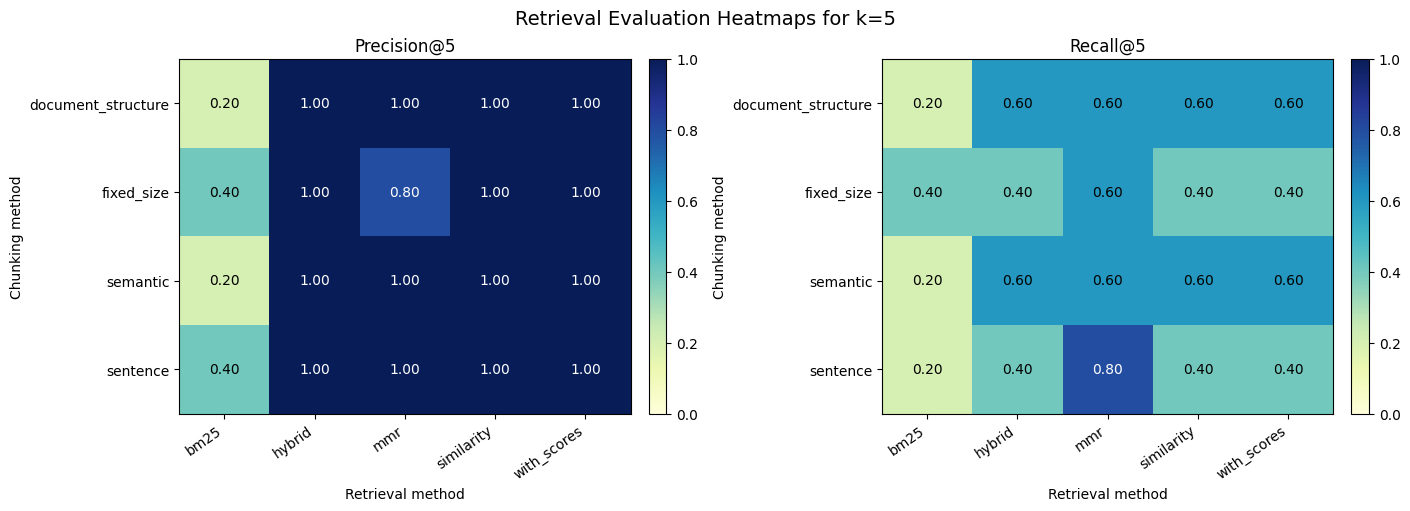

In [31]:
import os

matplotlib_cache_dir = os.path.abspath("outputs/evaluation/matplotlib_cache")
os.makedirs(matplotlib_cache_dir, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", matplotlib_cache_dir)
os.environ.setdefault("XDG_CACHE_HOME", matplotlib_cache_dir)

import matplotlib.pyplot as plt


def plot_retrieval_metric_heatmaps(eval_results, k=5, output_file=None):
    """Plot precision@k and recall@k heatmaps from eval_results."""
    k_results = eval_results[eval_results["k"] == k].copy()

    if k_results.empty:
        available_k = sorted(eval_results["k"].unique())
        raise ValueError(f"No rows found for k={k}. Available k values: {available_k}")

    metric_titles = {
        "precision@k": f"Precision@{k}",
        "recall@k": f"Recall@{k}",
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    for ax, metric in zip(axes, metric_titles):
        heatmap_data = k_results.pivot(
            index="chunking_method",
            columns="retrieval_method",
            values=metric,
        )

        image = ax.imshow(heatmap_data, cmap="YlGnBu", vmin=0, vmax=1, aspect="auto")
        ax.set_title(metric_titles[metric])
        ax.set_xlabel("Retrieval method")
        ax.set_ylabel("Chunking method")
        ax.set_xticks(range(len(heatmap_data.columns)))
        ax.set_xticklabels(heatmap_data.columns, rotation=35, ha="right")
        ax.set_yticks(range(len(heatmap_data.index)))
        ax.set_yticklabels(heatmap_data.index)

        for row_idx, chunking_method in enumerate(heatmap_data.index):
            for col_idx, retrieval_method in enumerate(heatmap_data.columns):
                value = heatmap_data.loc[chunking_method, retrieval_method]
                text_color = "white" if value >= 0.65 else "black"
                ax.text(col_idx, row_idx, f"{value:.2f}", ha="center", va="center", color=text_color)

        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(f"Retrieval Evaluation Heatmaps for k={k}", fontsize=14)

    if output_file:
        os.makedirs(os.path.dirname(output_file), exist_ok=True)
        fig.savefig(output_file, dpi=300, bbox_inches="tight")

    plt.show()
    return fig


plot_retrieval_metric_heatmaps(
    eval_results,
    k=5,
    output_file="outputs/evaluation/precision_recall_heatmap_k5.png",
);
